<a href="https://colab.research.google.com/github/Christian-Rojas-Rodriguez/introduction_data_cience/blob/master/credito_hipotecario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORTACIÓN DE DATOS: HIPOTECAS ARGENTINA

## Fuente 1: BCRA (CSV directo)

In [1]:
# --- Paquetes necesarios ------------------------------------
install.packages(c("httr", "jsonlite", "dplyr", "readr"))

library(httr)
library(jsonlite)
library(dplyr)
library(readr)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# ============================================================
# FUENTE 1: BCRA — Préstamos Hipotecarios UVA
# ============================================================

url_bcra <- "https://www.bcra.gob.ar/pdfs/BCRAyVos/HIPOTECA.CSV"

hipotecas_bcra <- tryCatch({
  read_delim(
    url_bcra,
    delim = ";",           # el BCRA suele usar punto y coma
    locale = locale(
      encoding  = "latin1",
      decimal_mark   = ",",
      grouping_mark  = "."
    ),
    col_names = TRUE,
    show_col_types = FALSE
  )
}, error = function(e) {
  message("⚠️  Error al leer BCRA: ", e$message)
  NULL
})

# Vista rápida
if (!is.null(hipotecas_bcra)) {
  cat("✅ BCRA cargado:", nrow(hipotecas_bcra), "filas x",
      ncol(hipotecas_bcra), "columnas\n")
  glimpse(hipotecas_bcra)
}

✅ BCRA cargado: 380 filas x 22 columnas
Rows: 380
Columns: 22
$ `Código de Entidad`                          <dbl> 7, 11, 11, 11, 11, 11, 11…
$ `Descripción de Entidad`                     <chr> "BANCO DE GALICIA Y BUENO…
$ `Fecha de Información`                       <date> 2026-02-18, 2025-11-28, …
$ `Nombre completo del Préstamo Hipotecario`   <chr> "PRESTAMOSHIPOTECARIOSUVA…
$ `Nombre corto del Préstamo Hipotecario`      <chr> "PHUVA", "SECTOR PUBLICO"…
$ Denominación                                 <chr> "UVA", "UVA", "UVA", "UVA…
$ `Monto máximo otorgable del préstamo`        <dbl> 999999999, 521192700, 521…
$ `Plazo máximo otorgable`                     <dbl> 240, 360, 360, 180, 360, …
$ `Ingreso mínimo mensual solicitado`          <dbl> 310000, 1097441, 1024692,…
$ `Antigüedad laboral mínima (meses)`          <dbl> 12, 12, 12, 12, 12, 12, 1…
$ `Edad máxima solicitada`                     <dbl> 55, 85, 85, 85, 85, 85, 8…
$ `Relación cuota/ingreso (%)`                 <dbl> 25, 3

In [10]:
# ============================================================
# DESCARGA FINAL — URLs reales del CDN de Buenos Aires Data
# ============================================================

library(httr)
library(readr)
library(dplyr)

set_config(config(ssl_verifypeer = FALSE))

leer_cdn <- function(url, nombre) {
  tryCatch({
    res   <- GET(url, config(ssl_verifypeer = FALSE),
                 add_headers(`User-Agent` = "Mozilla/5.0"))
    texto <- content(res, "text", encoding = "UTF-8")
    datos <- read_delim(
      I(texto),
      delim           = ";",
      locale          = locale(encoding = "UTF-8",
                               decimal_mark  = ",",
                               grouping_mark = "."),
      show_col_types  = FALSE
    )
    cat("✅", nombre, ":", nrow(datos), "filas x", ncol(datos), "columnas\n")
    datos
  }, error = function(e) {
    message("⚠️  Error en ", nombre, ": ", e$message)
    NULL
  })
}

In [11]:
# --- Dataset 2: Montos créditos hipotecarios UVA ------------
hipotecas_uva <- leer_cdn(
  url    = "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/instituto-de-vivienda/mercado-inmobiliario/montos-creditos-hipotecarios-uva.csv",
  nombre = "Hipotecas UVA"
)

# --- Dataset 3: Precio de venta de departamentos ------------
precio_venta <- leer_cdn(
  url    = "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/instituto-de-vivienda/mercado-inmobiliario/precio-venta-deptos.csv",
  nombre = "Precio venta deptos"
)


# ============================================================
# VISTA PREVIA
# ============================================================
cat("\n--- Hipotecas UVA ---\n");     glimpse(hipotecas_uva)
cat("\n--- Precio venta ---\n");      glimpse(precio_venta)


# ============================================================
# GUARDAR LOCALMENTE
# ============================================================
if (!is.null(hipotecas_uva))    write_csv(hipotecas_uva,    "hipotecas_uva.csv")
if (!is.null(precio_venta))     write_csv(precio_venta,     "precio_venta.csv")

cat("\n💾 CSVs guardados localmente.\n")

New names:
• `` -> `...5`
• `` -> `...6`


✅ Hipotecas UVA : 60 filas x 6 columnas
✅ Precio venta deptos : 7296 filas x 7 columnas

--- Hipotecas UVA ---
Rows: 60
Columns: 6
$ año_mes                                              <chr> "2016-05", "2016-…
$ `Monto operado prestamos de UVA (en miles de pesos)` <dbl> 2075, 14247, 3562…
$ `Var. mensual (%)`                                   <chr> NA, "586.60240963…
$ `Var. Anual (%)`                                     <chr> NA, NA, NA, NA, N…
$ ...5                                                 <chr> NA, NA, NA, NA, N…
$ ...6                                                 <chr> NA, NA, NA, NA, N…

--- Precio venta ---
Rows: 7,296
Columns: 7
$ barrio      <chr> "Agronomia", "Agronomia", "Agronomia", "Agronomia", "Agron…
$ año         <dbl> 2010, 2010, 2010, 2010, 2011, 2011, 2011, 2011, 2012, 2012…
$ trimestre   <dbl> 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4…
$ precio_prom <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ ambientes   <chr> "2 a

# LIMPIEZA Y PREPARACIÓN DE LOS 3 DATASETS ÚTILES

In [13]:
library(dplyr)
library(tidyr)
library(lubridate)
library(stringr)
library(readr)



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




## 1. BCRA — Préstamos hipotecarios UVA por entidad

In [14]:
# ============================================================
# 1. BCRA — Préstamos hipotecarios UVA por entidad
# ============================================================

bcra_clean <- hipotecas_bcra %>%
  # Renombrar columnas para trabajar más fácil
  rename(
    entidad          = `Descripción de Entidad`,
    fecha            = `Fecha de Información`,
    denominacion     = Denominación,
    monto_max        = `Monto máximo otorgable del préstamo`,
    plazo_max        = `Plazo máximo otorgable`,
    ingreso_min      = `Ingreso mínimo mensual solicitado`,
    antiguedad_min   = `Antigüedad laboral mínima (meses)`,
    edad_max         = `Edad máxima solicitada`,
    rel_cuota_ing    = `Relación cuota/ingreso (%)`,
    rel_monto_tas    = `Relación monto/tasación (%)`,
    tasa_anual_max   = `Tasa efectiva anual máxima`,
    tipo_tasa        = `Tipo de Tasa`,
    costo_financiero = `Costo financiero efectivo total máximo`,
    cuota_inicial    = `Cuota inicial a plazo máximo cada $100.000`
  ) %>%
  # Mantener solo columnas relevantes
  select(entidad, fecha, denominacion, monto_max, plazo_max,
         ingreso_min, antiguedad_min, edad_max, rel_cuota_ing,
         rel_monto_tas, tasa_anual_max, tipo_tasa,
         costo_financiero, cuota_inicial) %>%
  # Filtrar solo UVA (excluir pesos tradicionales si los hay)
  filter(denominacion == "UVA") %>%
  # Eliminar filas con NA en variables clave
  drop_na(tasa_anual_max, cuota_inicial, ingreso_min)

cat("✅ bcra_clean:", nrow(bcra_clean), "filas\n")
glimpse(bcra_clean)

✅ bcra_clean: 283 filas
Rows: 283
Columns: 14
$ entidad          <chr> "BANCO DE GALICIA Y BUENOS AIRES S.A.", "BANCO DE LA …
$ fecha            <date> 2026-02-18, 2025-11-28, 2025-11-28, 2025-11-28, 2025…
$ denominacion     <chr> "UVA", "UVA", "UVA", "UVA", "UVA", "UVA", "UVA", "UVA…
$ monto_max        <dbl> 999999999, 521192700, 521192700, 430190800, 430190800…
$ plazo_max        <dbl> 240, 360, 360, 180, 360, 180, 360, 360, 360, 360, 360…
$ ingreso_min      <dbl> 310000, 1097441, 1024692, 1295849, 1094693, 1516835, …
$ antiguedad_min   <dbl> 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 1…
$ edad_max         <dbl> 55, 85, 85, 85, 85, 85, 85, 85, 85, 85, 85, 85, 85, 8…
$ rel_cuota_ing    <dbl> 25, 30, 30, 25, 25, 25, 30, 25, 30, 25, 30, 25, 25, 2…
$ rel_monto_tas    <dbl> 70, 90, 90, 75, 75, 75, 90, 75, 90, 75, 90, 75, 75, 7…
$ tasa_anual_max   <dbl> 19.00, 12.69, 6.17, 12.69, 12.69, 12.69, 6.17, 12.69,…
$ tipo_tasa        <chr> "Fija", "Fija", "Fija", "Fija", "Fija", "Fija", "

## 2. HIPOTECAS UVA — Serie temporal de montos

In [15]:
# ============================================================
# 2. HIPOTECAS UVA — Serie temporal de montos
# ============================================================

uva_clean <- hipotecas_uva %>%
  # Eliminar columnas vacías
  select(año_mes,
         monto_miles = `Monto operado prestamos de UVA (en miles de pesos)`,
         var_mensual = `Var. mensual (%)`,
         var_anual   = `Var. Anual (%)`) %>%
  # Convertir variaciones a numérico
  mutate(
    var_mensual = as.numeric(str_replace(var_mensual, ",", ".")),
    var_anual   = as.numeric(str_replace(var_anual,   ",", ".")),
    fecha       = ym(año_mes),
    año         = year(fecha),
    mes         = month(fecha)
  ) %>%
  select(fecha, año, mes, monto_miles, var_mensual, var_anual) %>%
  drop_na(monto_miles)

cat("✅ uva_clean:", nrow(uva_clean), "filas\n")
glimpse(uva_clean)

Warning message:
“There were 2 warnings in `mutate()`.
The first warning was:
ℹ In argument: `var_mensual = as.numeric(str_replace(var_mensual, ",", "."))`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


✅ uva_clean: 60 filas
Rows: 60
Columns: 6
$ fecha       <date> 2016-05-01, 2016-06-01, 2016-07-01, 2016-08-01, 2016-09-0…
$ año         <dbl> 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2017, 2017…
$ mes         <dbl> 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, …
$ monto_miles <dbl> 2075, 14247, 35622, 127181, 238335, 394258, 465059, 819470…
$ var_mensual <dbl> NA, 586.6024096, 150.0315856, 257.0293639, 87.3982749, 65.…
$ var_anual   <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, 79224.7229…


## 3. PRECIO VENTA — Deptos por barrio/trimestre

In [16]:
# ============================================================
# 3. PRECIO VENTA — Deptos por barrio/trimestre
# ============================================================

precio_clean <- precio_venta %>%
  # Eliminar filas sin precio
  drop_na(precio_prom) %>%
  filter(precio_prom > 0) %>%
  # Crear variable de fecha aproximada (año + trimestre)
  mutate(
    fecha_aprox = as.Date(paste0(año, "-", (trimestre * 3) - 2, "-01")),
    ambientes   = as.factor(ambientes),
    estado      = as.factor(estado),
    barrio      = str_to_title(barrio)
  ) %>%
  select(barrio, comuna, año, trimestre, fecha_aprox,
         ambientes, estado, precio_prom)

cat("✅ precio_clean:", nrow(precio_clean), "filas\n")
glimpse(precio_clean)

✅ precio_clean: 3085 filas
Rows: 3,085
Columns: 8
$ barrio      <chr> "Agronomia", "Agronomia", "Agronomia", "Agronomia", "Agron…
$ comuna      <dbl> 15, 15, 15, 15, 15, 15, 15, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, …
$ año         <dbl> 2016, 2016, 2016, 2016, 2017, 2017, 2017, 2010, 2010, 2010…
$ trimestre   <dbl> 1, 2, 3, 4, 1, 2, 3, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1…
$ fecha_aprox <date> 2016-01-01, 2016-04-01, 2016-07-01, 2016-10-01, 2017-01-0…
$ ambientes   <fct> 2 ambientes, 2 ambientes, 2 ambientes, 2 ambientes, 2 ambi…
$ estado      <fct> Usado, Usado, Usado, Usado, Usado, Usado, Usado, Usado, Us…
$ precio_prom <dbl> 2018, 2032, 2095, 2052, 2140, 2203, 2303, 1574, 1610, 1665…


In [17]:
# ============================================================
# RESUMEN DE NULOS POR DATASET
# ============================================================

cat("\n--- NAs en bcra_clean ---\n")
colSums(is.na(bcra_clean))

cat("\n--- NAs en uva_clean ---\n")
colSums(is.na(uva_clean))

cat("\n--- NAs en precio_clean ---\n")
colSums(is.na(precio_clean))


# ============================================================
# GUARDAR LIMPIOS
# ============================================================
write_csv(bcra_clean,    "bcra_clean.csv")
write_csv(uva_clean,     "uva_clean.csv")
write_csv(precio_clean,  "precio_clean.csv")

cat("\n💾 Datasets limpios guardados.\n")


--- NAs en bcra_clean ---


entidad            fecha     denominacion        monto_max 
               0                0                0                0 
       plazo_max      ingreso_min   antiguedad_min         edad_max 
               0                0                0                0 
   rel_cuota_ing    rel_monto_tas   tasa_anual_max        tipo_tasa 
               0                0                0                0 
costo_financiero    cuota_inicial 
               0                0


--- NAs en uva_clean ---


fecha         año         mes monto_miles var_mensual   var_anual 
          0           0           0           0          23          34


--- NAs en precio_clean ---


barrio      comuna         año   trimestre fecha_aprox   ambientes 
          0           0           0           0           0           0 
     estado precio_prom 
          0           0


💾 Datasets limpios guardados.


In [18]:
# ============================================================
# REVISAR RANGOS TEMPORALES DE CADA DATASET
# ============================================================

cat("=== BCRA ===\n")
cat("Rango de fechas:", format(min(bcra_clean$fecha)), "→",
    format(max(bcra_clean$fecha)), "\n")
cat("Fechas únicas:\n")
print(sort(unique(bcra_clean$fecha)))

cat("\n=== UVA (serie temporal) ===\n")
cat("Rango:", format(min(uva_clean$fecha)), "→",
    format(max(uva_clean$fecha)), "\n")

cat("\n=== PRECIO VENTA ===\n")
cat("Rango de años:", min(precio_clean$año), "→", max(precio_clean$año), "\n")
cat("Trimestres disponibles:\n")
precio_clean %>% count(año, trimestre) %>% print(n = 40)

=== BCRA ===
Rango de fechas: 2024-12-23 → 2026-03-19 
Fechas únicas:
 [1] "2024-12-23" "2025-01-28" "2025-07-10" "2025-09-09" "2025-09-26"
 [6] "2025-10-02" "2025-11-28" "2025-12-16" "2026-01-23" "2026-02-09"
[11] "2026-02-12" "2026-02-18" "2026-02-23" "2026-02-27" "2026-03-04"
[16] "2026-03-11" "2026-03-16" "2026-03-17" "2026-03-18" "2026-03-19"

=== UVA (serie temporal) ===
Rango: 2016-05-01 → 2021-04-01 

=== PRECIO VENTA ===
Rango de años: 2010 → 2019 
Trimestres disponibles:
# A tibble: 38 × 3
     año trimestre     n
   <dbl>     <dbl> <int>
 1  2010         1    77
 2  2010         2    70
 3  2010         3   103
 4  2010         4   115
 5  2011         1   104
 6  2011         2    84
 7  2011         3   101
 8  2011         4    44
 9  2012         1    31
10  2012         2    40
11  2012         3    26
12  2012         4    29
13  2013         1    20
14  2013         2    27
15  2013         3    39
16  2013         4    50
17  2014         1    32
18  2014         2  

# CRUCE uva_clean + precio_clean  →  período 2016 Q1–2019 Q2

In [19]:
# ============================================================
# CRUCE uva_clean + precio_clean  →  período 2016 Q1–2019 Q2
# ============================================================

library(dplyr)
library(lubridate)

# --- 1. Agregar uva_clean a nivel trimestral -----------------
uva_trimestral <- uva_clean %>%
  mutate(trimestre = quarter(fecha)) %>%
  group_by(año, trimestre) %>%
  summarise(
    monto_trim      = sum(monto_miles, na.rm = TRUE),   # monto total del trimestre
    var_mens_media  = mean(var_mensual, na.rm = TRUE),  # variación mensual promedio
    .groups = "drop"
  )

cat("UVA trimestral:\n")
print(uva_trimestral)

# --- 2. Agregar precio_clean a nivel trimestral --------------
precio_trimestral <- precio_clean %>%
  group_by(año, trimestre) %>%
  summarise(
    precio_medio   = mean(precio_prom,  na.rm = TRUE),
    precio_mediano = median(precio_prom, na.rm = TRUE),
    n_obs          = n(),
    .groups = "drop"
  )

# --- 3. Cruce por año + trimestre ----------------------------
datos_cruzados <- precio_trimestral %>%
  inner_join(uva_trimestral, by = c("año", "trimestre")) %>%
  filter(año >= 2016, !(año == 2019 & trimestre > 2)) %>%  # límite UVA
  mutate(
    fecha  = as.Date(paste0(año, "-", (trimestre * 3) - 2, "-01")),
    log_monto  = log(monto_trim),       # útil para regresión
    log_precio = log(precio_medio)
  ) %>%
  arrange(fecha)

cat("\n✅ Datos cruzados:", nrow(datos_cruzados), "filas\n")
glimpse(datos_cruzados)

cat("\nPeríodo cubierto:", format(min(datos_cruzados$fecha)),
    "→", format(max(datos_cruzados$fecha)), "\n")

cat("\nCorrelación monto UVA vs precio promedio:",
    round(cor(datos_cruzados$monto_trim, datos_cruzados$precio_medio), 3), "\n")

cat("Correlación log(monto) vs log(precio):",
    round(cor(datos_cruzados$log_monto, datos_cruzados$log_precio), 3), "\n")

UVA trimestral:
# A tibble: 21 × 4
     año trimestre monto_trim var_mens_media
   <dbl>     <int>      <dbl>          <dbl>
 1  2016         2      16322         587.  
 2  2016         3     401138         165.  
 3  2016         4    1678787          53.2 
 4  2017         1    2477885          17.3 
 5  2017         2    5523992          33.6 
 6  2017         3   17386737          41.5 
 7  2017         4   28870908          16.3 
 8  2018         1   32877998           9.95
 9  2018         2   29389921         -24.1 
10  2018         3   13474727         -13.6 
# ℹ 11 more rows

✅ Datos cruzados: 13 filas
Rows: 13
Columns: 10
$ año            <dbl> 2016, 2016, 2016, 2017, 2017, 2017, 2017, 2018, 2018, 2…
$ trimestre      <dbl> 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2
$ precio_medio   <dbl> 2302.077, 2347.661, 2397.358, 2439.241, 2485.717, 2577.…
$ precio_mediano <dbl> 2176.0, 2234.5, 2257.0, 2282.0, 2346.5, 2386.0, 2487.0,…
$ n_obs          <int> 117, 112, 120, 133, 120, 115, 99, 9

# EDA DEL CRUCE — uva_clean + precio_clean (2016–2019)

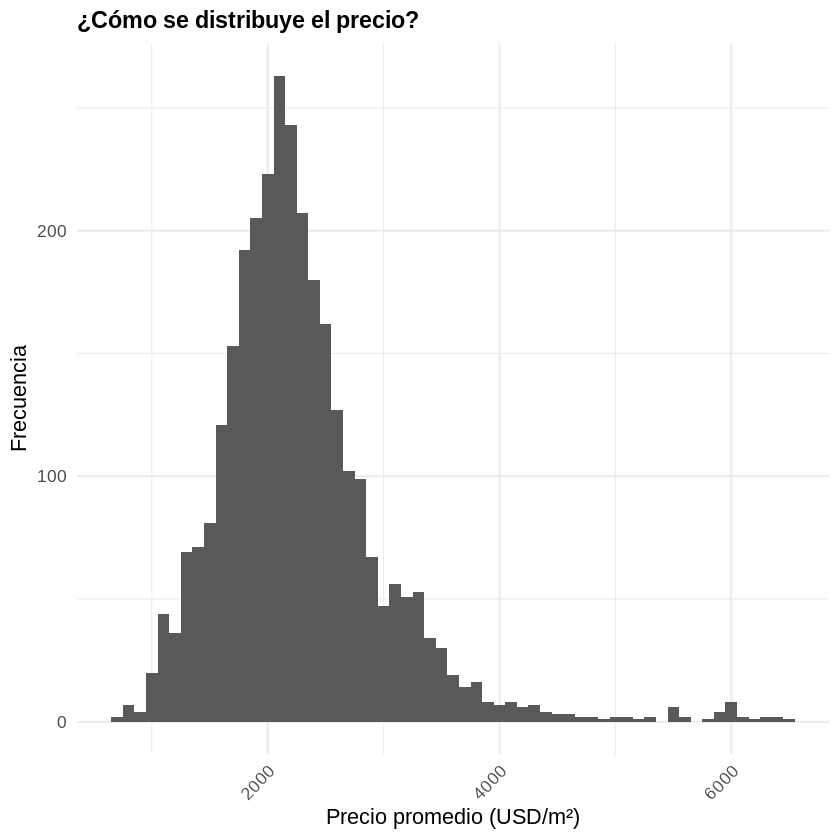

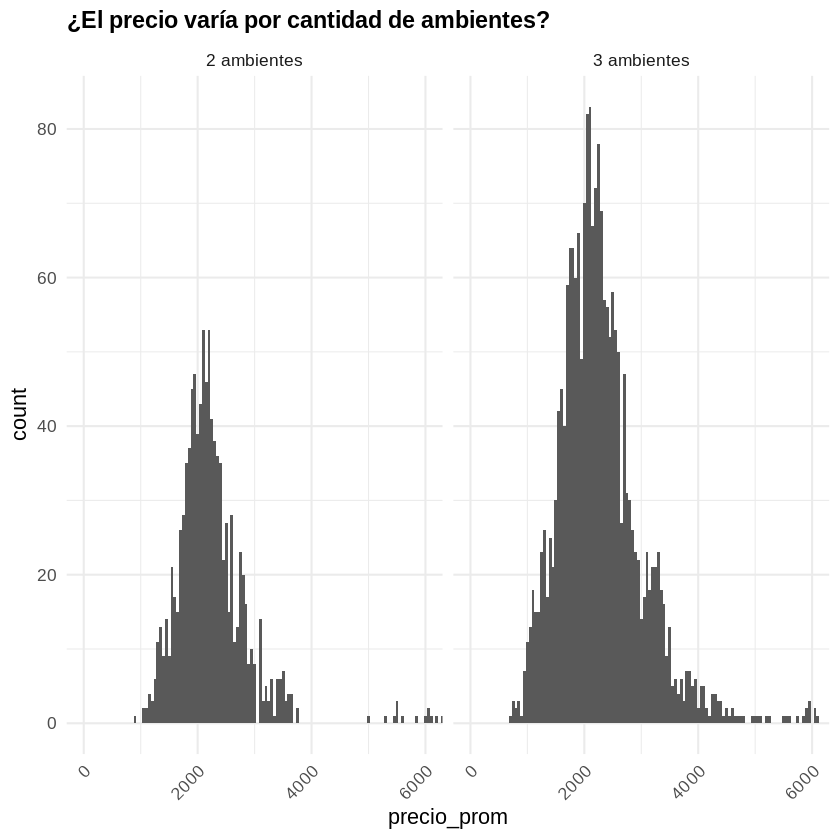

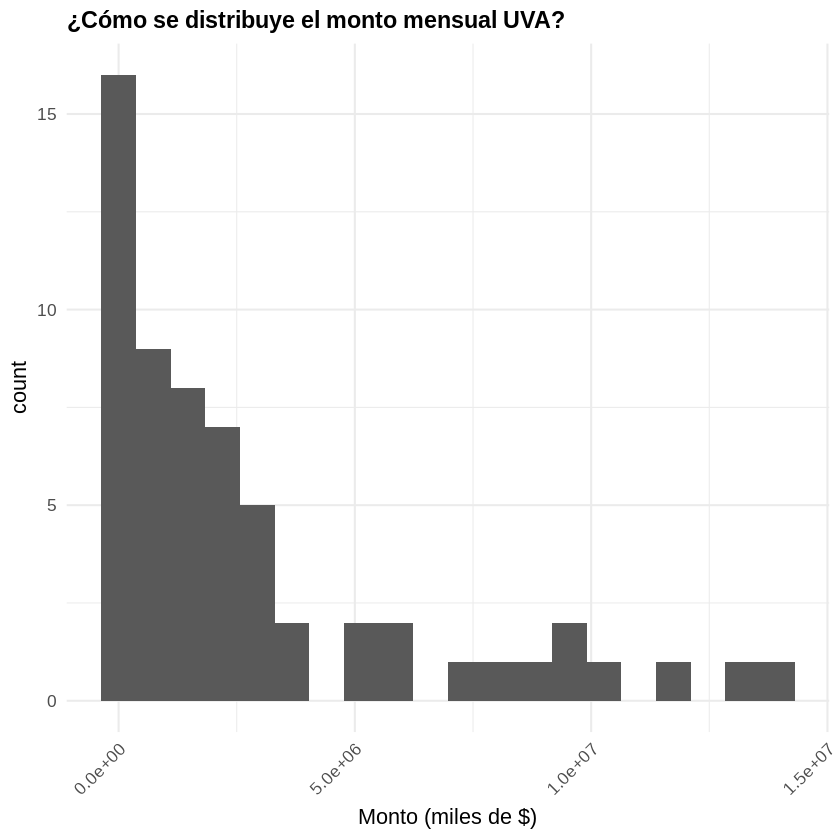

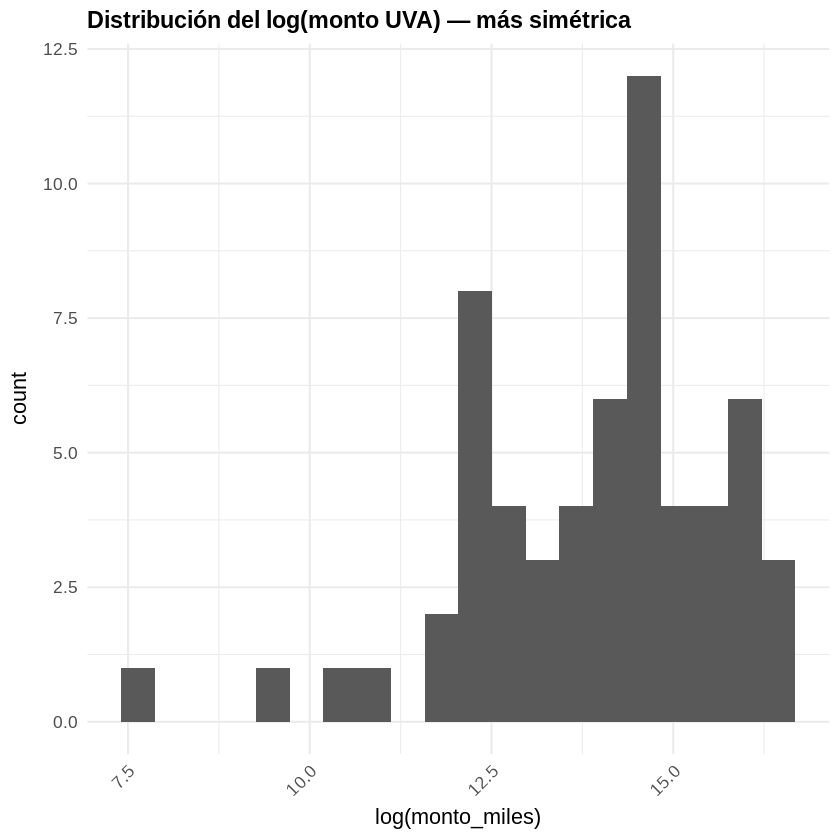

entidad,tasa_anual_max,cuota_inicial,plazo_max
<chr>,<dbl>,<dbl>,<dbl>
BANCO DE GALICIA Y BUENOS AIRES S.A.,19.00,1467,240
BANCO BBVA ARGENTINA S.A.,18.39,17307,360
BANCO BBVA ARGENTINA S.A.,18.39,17307,360
BANCO BBVA ARGENTINA S.A.,18.39,17307,360
BANCO BBVA ARGENTINA S.A.,18.39,14332,360
BANCO BBVA ARGENTINA S.A.,18.39,17307,360
BANCO BBVA ARGENTINA S.A.,18.39,14332,360
BANCO BBVA ARGENTINA S.A.,18.39,17307,360
BANCO BBVA ARGENTINA S.A.,16.07,12722,360


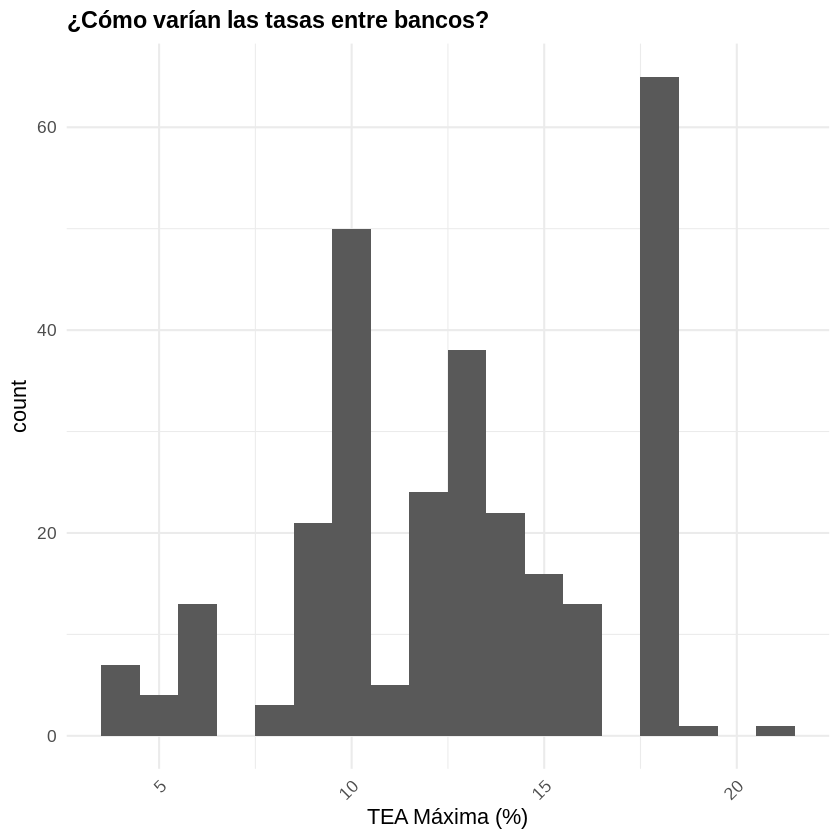

In [28]:
library(tidyverse)
library(modelr)

options(na.action = na.warn)


# ============================================================
# PASO 1 — Preguntas iniciales (R4DS 7.2)
# ============================================================
# Pregunta 1: ¿Cómo varía el precio de los departamentos?
# Pregunta 2: ¿El crédito UVA se relaciona con el precio?
# Pregunta 3: ¿Qué variables del BCRA determinan la cuota?


# ============================================================
# PASO 2 — Variación dentro de cada variable (R4DS 7.3)
# ============================================================

# --- 2A: Distribución del precio de departamentos -----------
ggplot(precio_clean, aes(precio_prom)) +
  geom_histogram(binwidth = 100) +
  labs(title = "¿Cómo se distribuye el precio?",
       x = "Precio promedio (USD/m²)", y = "Frecuencia")

# Valores típicos: ¿hay subgrupos?
ggplot(precio_clean, aes(precio_prom)) +
  geom_histogram(binwidth = 50) +
  coord_cartesian(xlim = c(0, 6000)) +
  facet_wrap(~ambientes) +
  labs(title = "¿El precio varía por cantidad de ambientes?")

# --- 2B: Distribución del monto UVA -------------------------
ggplot(uva_clean, aes(monto_miles)) +
  geom_histogram(bins = 20) +
  labs(title = "¿Cómo se distribuye el monto mensual UVA?",
       x = "Monto (miles de $)")

# Fuertemente sesgado → inspeccionar en log
ggplot(uva_clean, aes(log(monto_miles))) +
  geom_histogram(bins = 20) +
  labs(title = "Distribución del log(monto UVA) — más simétrica")

# --- 2C: Distribución de tasa anual BCRA --------------------
ggplot(bcra_clean, aes(tasa_anual_max)) +
  geom_histogram(binwidth = 1) +
  labs(title = "¿Cómo varían las tasas entre bancos?",
       x = "TEA Máxima (%)")

# Valores inusuales?
bcra_clean %>%
  filter(tasa_anual_max > 15 | tasa_anual_max < 5) %>%
  select(entidad, tasa_anual_max, cuota_inicial, plazo_max)


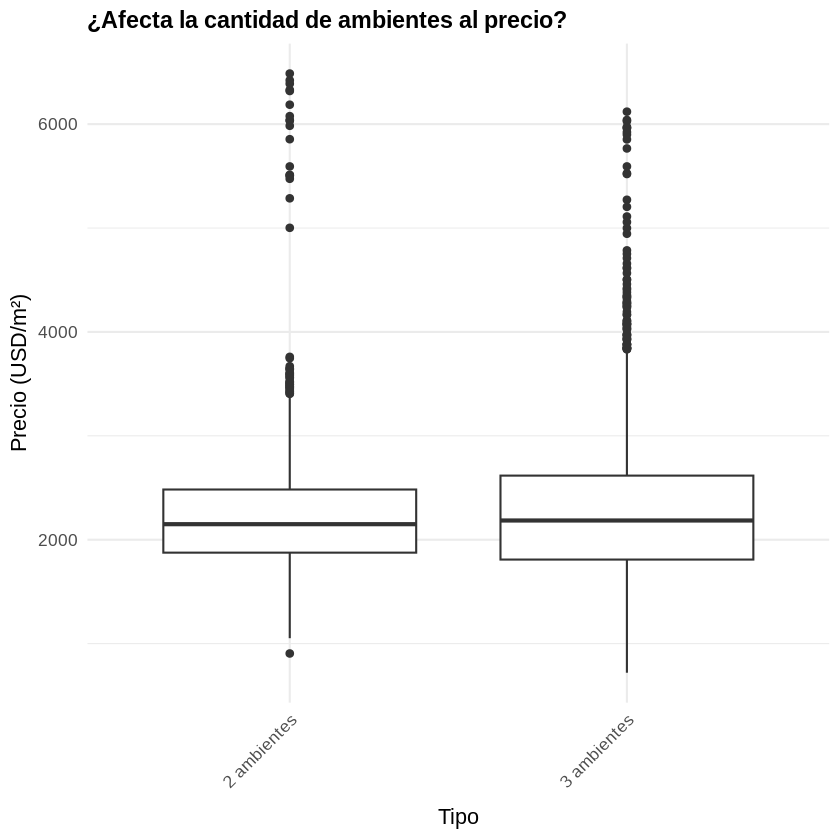

`geom_smooth()` using formula = 'y ~ x'


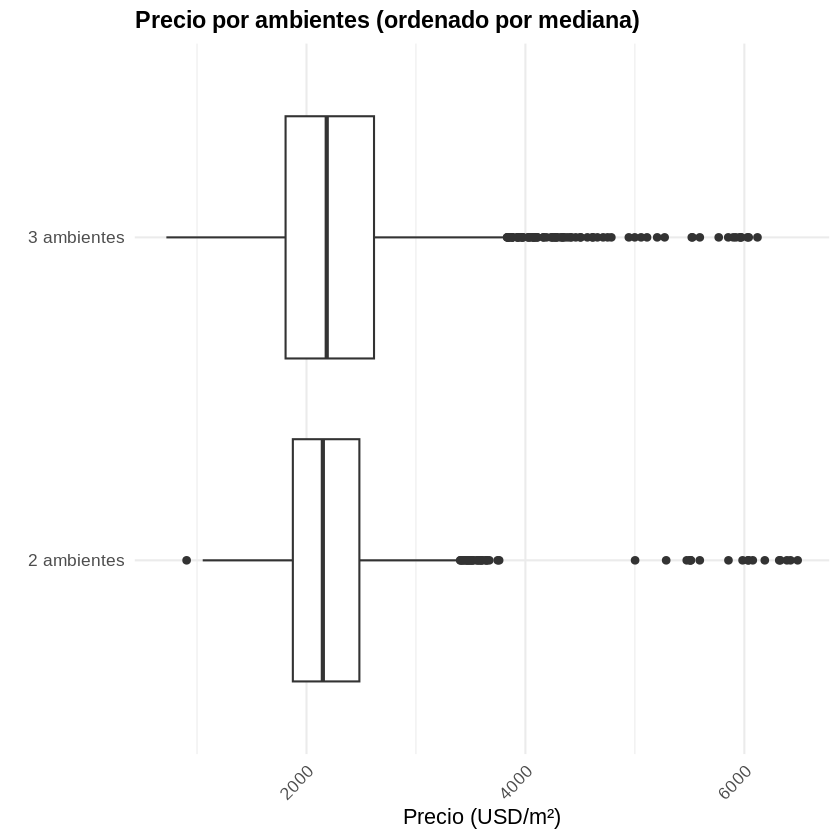

`geom_smooth()` using formula = 'y ~ x'


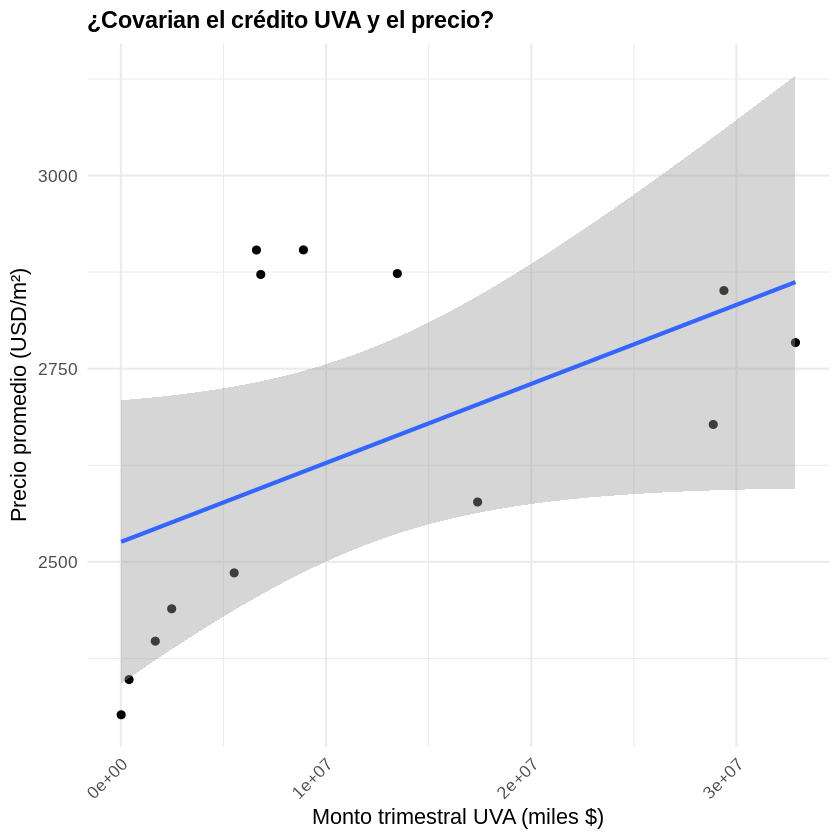

`geom_smooth()` using formula = 'y ~ x'


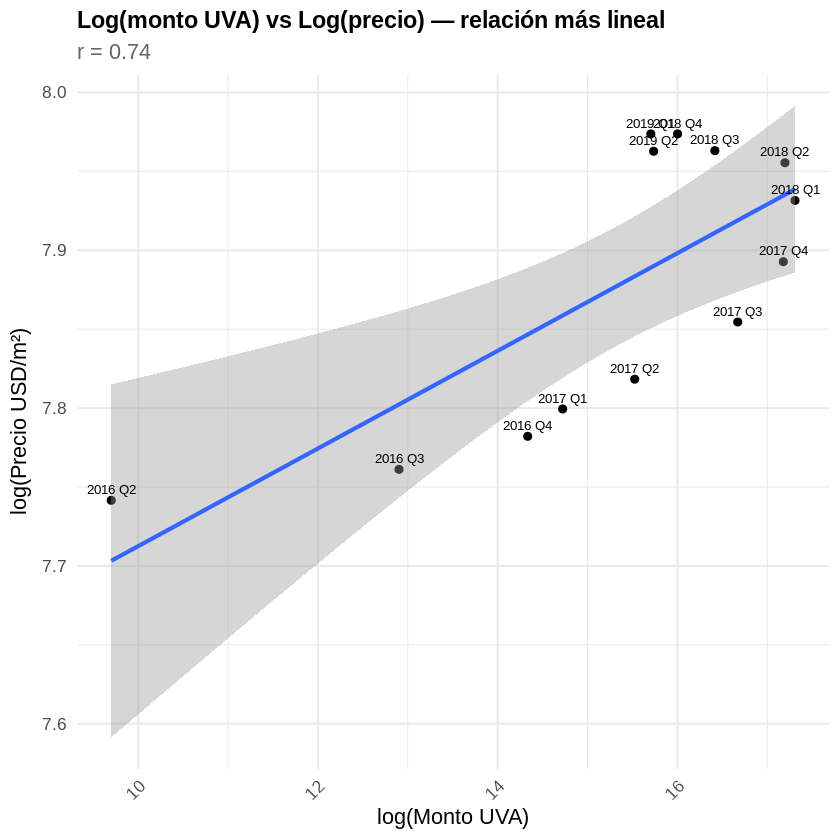

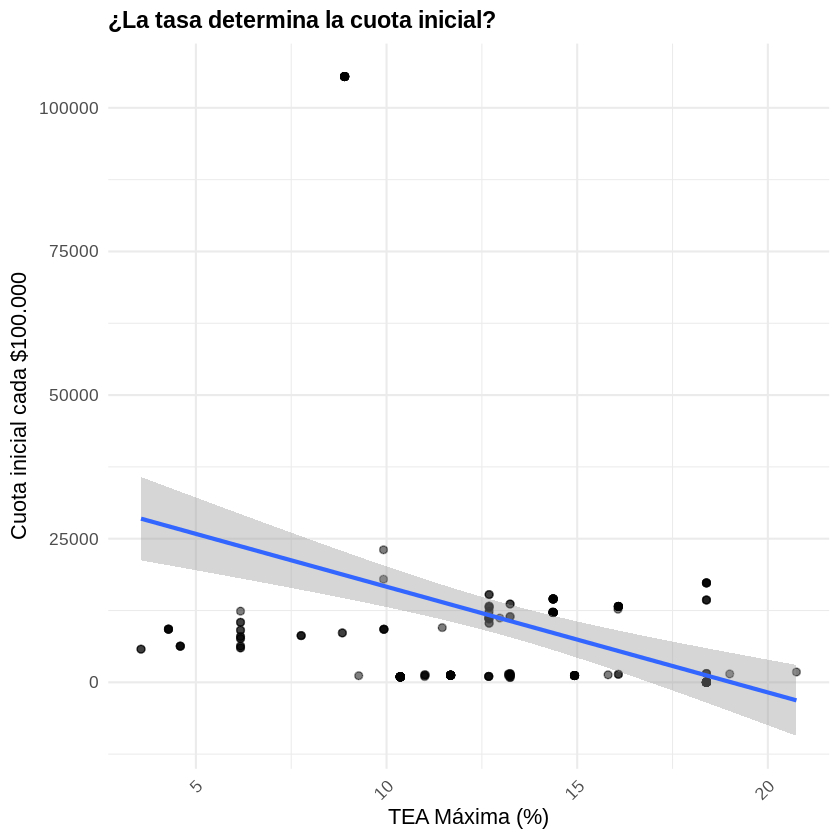

In [29]:
# ============================================================
# PASO 3 — Covariación entre variables (R4DS 7.5)
# ============================================================

# --- 3A: Categórica + continua: precio por ambientes y estado
ggplot(precio_clean, aes(ambientes, precio_prom)) +
  geom_boxplot() +
  labs(title = "¿Afecta la cantidad de ambientes al precio?",
       x = "Tipo", y = "Precio (USD/m²)")

ggplot(precio_clean, aes(reorder(ambientes, precio_prom, FUN = median),
                          precio_prom)) +
  geom_boxplot() +
  coord_flip() +
  labs(title = "Precio por ambientes (ordenado por mediana)",
       x = NULL, y = "Precio (USD/m²)")

# --- 3B: Dos continuas: ¿monto UVA vs precio? ---------------
ggplot(datos_cruzados, aes(monto_trim, precio_medio)) +
  geom_point() +
  geom_smooth(method = "lm", se = TRUE) +
  labs(title = "¿Covarian el crédito UVA y el precio?",
       x = "Monto trimestral UVA (miles $)",
       y = "Precio promedio (USD/m²)")

# Relación no lineal → probar log
ggplot(datos_cruzados, aes(log(monto_trim), log(precio_medio))) +
  geom_point() +
  geom_smooth(method = "lm", se = TRUE) +
  geom_text(aes(label = paste0(año, " Q", trimestre)),
            vjust = -0.7, size = 2.8) +
  labs(title = "Log(monto UVA) vs Log(precio) — relación más lineal",
       subtitle = paste0("r = ", round(cor(datos_cruzados$log_monto,
                                           datos_cruzados$log_precio), 3)),
       x = "log(Monto UVA)", y = "log(Precio USD/m²)")

# --- 3C: Tasa vs cuota (BCRA) --------------------------------
ggplot(bcra_clean, aes(tasa_anual_max, cuota_inicial)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(title = "¿La tasa determina la cuota inicial?",
       x = "TEA Máxima (%)", y = "Cuota inicial cada $100.000")

# MODELOS DE REGRESIÓN LINEAL — Hipotecas Argentina

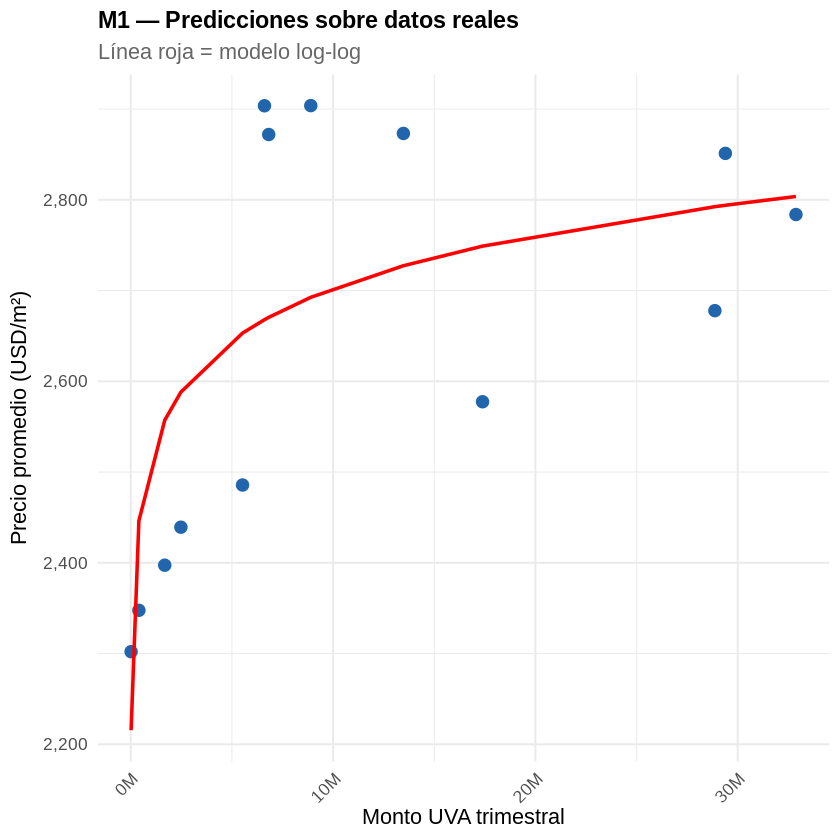

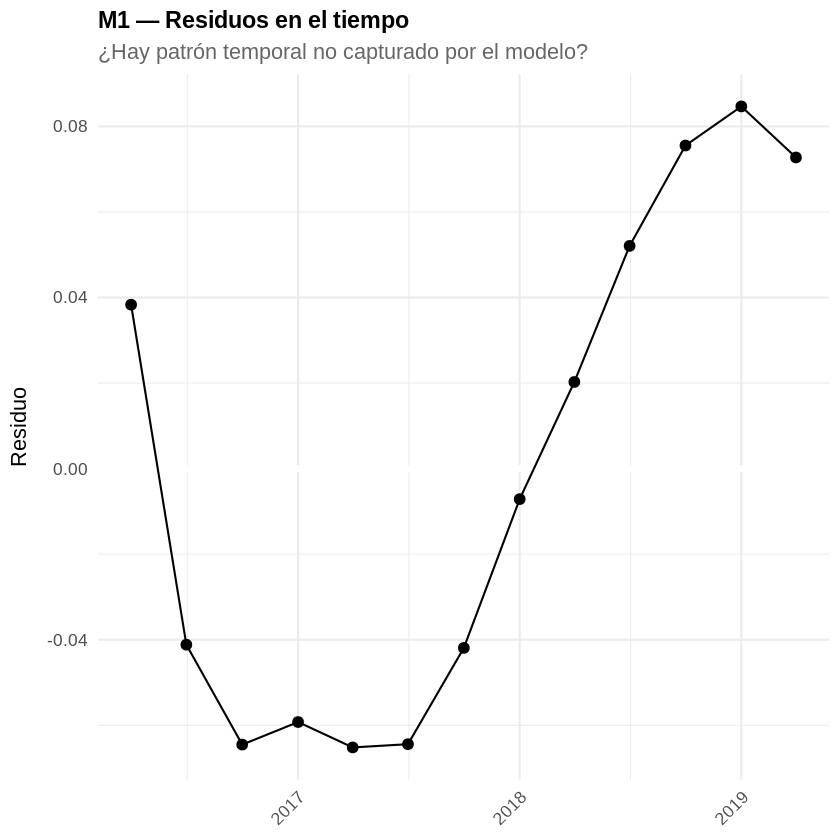

=== M1 summary ===



Call:
lm(formula = log_precio ~ log_monto, data = datos_cruzados)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.065176 -0.059241 -0.007128  0.052059  0.084660 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 7.403066   0.131159   56.44 6.66e-15 ***
log_monto   0.030946   0.008477    3.65  0.00382 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.06203 on 11 degrees of freedom
Multiple R-squared:  0.5478,	Adjusted R-squared:  0.5067 
F-statistic: 13.33 on 1 and 11 DF,  p-value: 0.003818


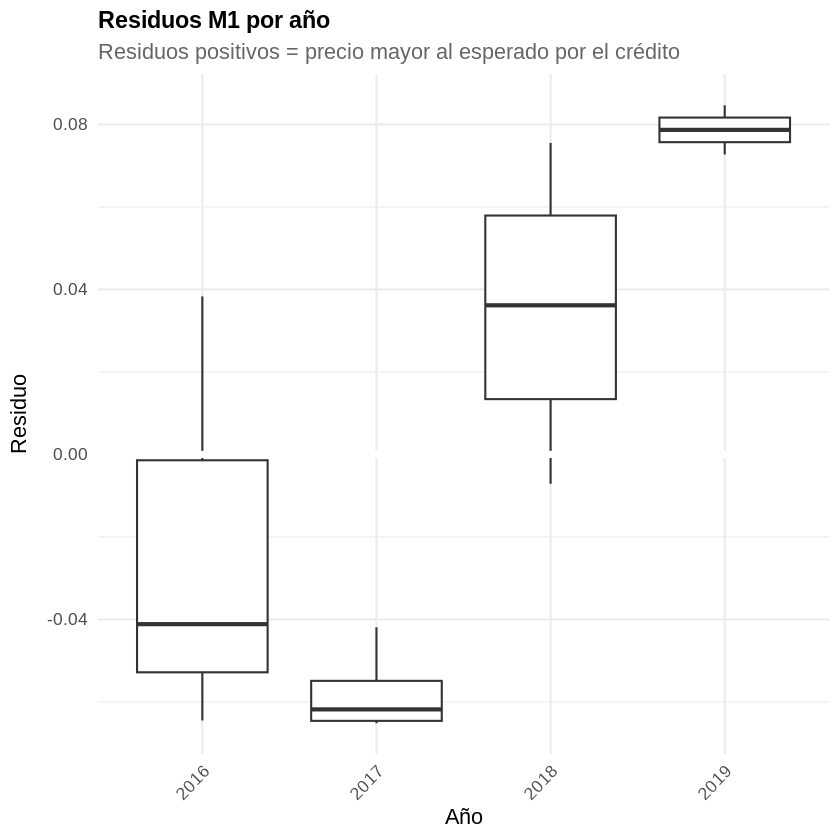

In [31]:
# ============================================================
# PASO 4 — MODELOS al estilo R4DS (Cap. 24)
# El flujo es: modelo → add_predictions → add_residuals
#              → visualizar residuos → nueva pregunta
# ============================================================

# ============================================================
# M1 — Log(precio) ~ Log(monto UVA)
# ============================================================

# Primero: el patrón es lineal en log-log (ya lo vimos arriba)
m1 <- lm(log_precio ~ log_monto, data = datos_cruzados)

# Visualizar predicciones sobre los datos originales
datos_cruzados %>%
  add_predictions(m1, "pred_log") %>%
  mutate(pred_precio = exp(pred_log)) %>%
  ggplot(aes(monto_trim, precio_medio)) +
  geom_point(color = "#2166ac", size = 3) +
  geom_line(aes(y = pred_precio), color = "red", linewidth = 1) +
  scale_x_continuous(labels = scales::label_comma(scale = 1e-6, suffix = "M")) +
  scale_y_continuous(labels = scales::label_comma()) +
  labs(title = "M1 — Predicciones sobre datos reales",
       subtitle = "Línea roja = modelo log-log",
       x = "Monto UVA trimestral", y = "Precio promedio (USD/m²)")

# Residuos: ¿queda patrón sin explicar?
datos_cruzados %>%
  add_residuals(m1, "resid") %>%
  ggplot(aes(fecha, resid)) +
  geom_ref_line(h = 0) +
  geom_line() +
  geom_point(size = 2.5) +
  labs(title = "M1 — Residuos en el tiempo",
       subtitle = "¿Hay patrón temporal no capturado por el modelo?",
       x = NULL, y = "Residuo")

# Nueva pregunta: ¿los residuos se relacionan con el año?
datos_cruzados %>%
  add_residuals(m1, "resid") %>%
  ggplot(aes(factor(año), resid)) +
  geom_boxplot() +
  geom_ref_line(h = 0) +
  labs(title = "Residuos M1 por año",
       subtitle = "Residuos positivos = precio mayor al esperado por el crédito",
       x = "Año", y = "Residuo")

cat("=== M1 summary ===\n")
summary(m1)

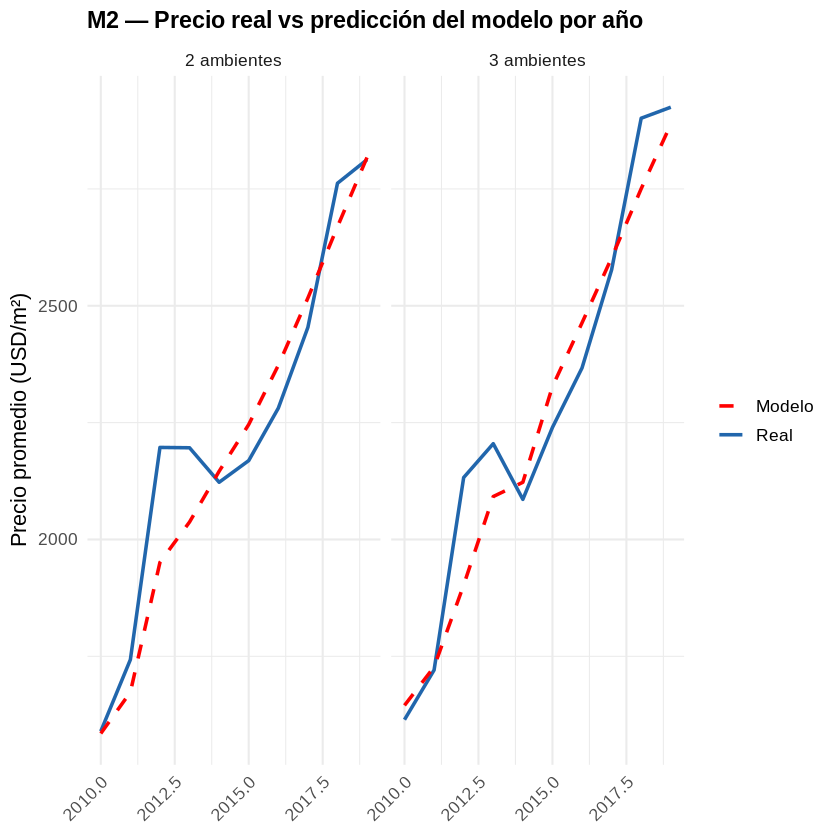

=== M2 summary ===



Call:
lm(formula = precio_prom ~ año_c + ambientes + estado + comuna, 
    data = precio_modelo)

Residuals:
    Min      1Q  Median      3Q     Max 
-1271.0  -176.8   -36.5   139.4  3576.7 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)           2205.57      38.87  56.750  < 2e-16 ***
año_c                  134.33       2.77  48.491  < 2e-16 ***
ambientes3 ambientes  -107.62      18.96  -5.676 1.51e-08 ***
estadoUsado           -369.94      19.76 -18.725  < 2e-16 ***
comuna2                540.21      48.13  11.223  < 2e-16 ***
comuna3               -616.38      41.66 -14.796  < 2e-16 ***
comuna4               -631.22      41.83 -15.090  < 2e-16 ***
comuna5               -346.49      41.57  -8.335  < 2e-16 ***
comuna6               -164.55      45.72  -3.599 0.000324 ***
comuna7               -502.75      41.31 -12.171  < 2e-16 ***
comuna8              -1043.41      64.92 -16.072  < 2e-16 ***
comuna9               -723.56      40.09 -18.051 

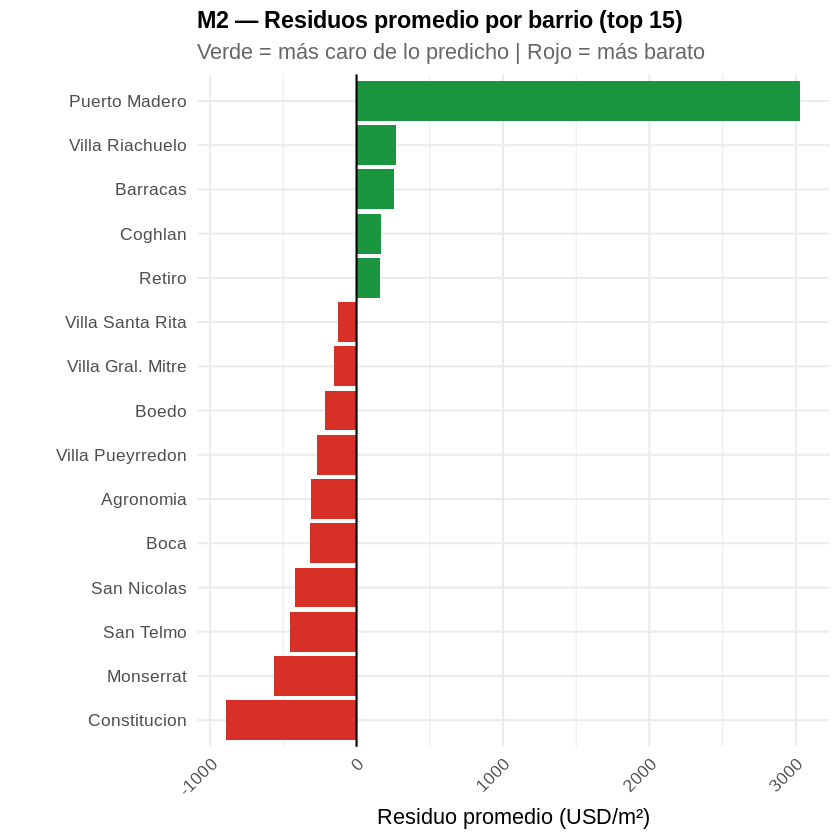

In [32]:
# ============================================================
# M2 — Precio ~ año + ambientes + estado + comuna
# ============================================================

precio_modelo <- precio_clean %>%
  mutate(
    comuna = as.factor(comuna),
    año_c  = año - 2010
  )

m2 <- lm(precio_prom ~ año_c + ambientes + estado + comuna,
          data = precio_modelo)

# Predicciones: ¿captura la tendencia anual?
precio_modelo %>%
  add_predictions(m2) %>%
  group_by(año, ambientes) %>%
  summarise(
    pred_media  = mean(pred,        na.rm = TRUE),
    precio_real = mean(precio_prom, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  ggplot(aes(año)) +
  geom_line(aes(y = precio_real, color = "Real"),    linewidth = 1) +
  geom_line(aes(y = pred_media,  color = "Modelo"),
            linetype = "dashed", linewidth = 1) +
  facet_wrap(~ambientes) +
  scale_color_manual(values = c("Real" = "#2166ac", "Modelo" = "red")) +
  labs(title = "M2 — Precio real vs predicción del modelo por año",
       x = NULL, y = "Precio promedio (USD/m²)", color = NULL)

# Residuos: ¿quedan patrones por barrio?
precio_modelo %>%
  add_residuals(m2, "resid") %>%
  group_by(barrio) %>%
  summarise(resid_medio = mean(resid), n = n()) %>%
  filter(n >= 10) %>%
  slice_max(abs(resid_medio), n = 15) %>%
  mutate(barrio = fct_reorder(barrio, resid_medio)) %>%
  ggplot(aes(resid_medio, barrio,
             fill = resid_medio > 0)) +
  geom_col() +
  scale_fill_manual(values = c("TRUE" = "#1a9641", "FALSE" = "#d73027"),
                    guide = "none") +
  geom_vline(xintercept = 0) +
  labs(title = "M2 — Residuos promedio por barrio (top 15)",
       subtitle = "Verde = más caro de lo predicho | Rojo = más barato",
       x = "Residuo promedio (USD/m²)", y = NULL)

cat("=== M2 summary ===\n")
summary(m2)

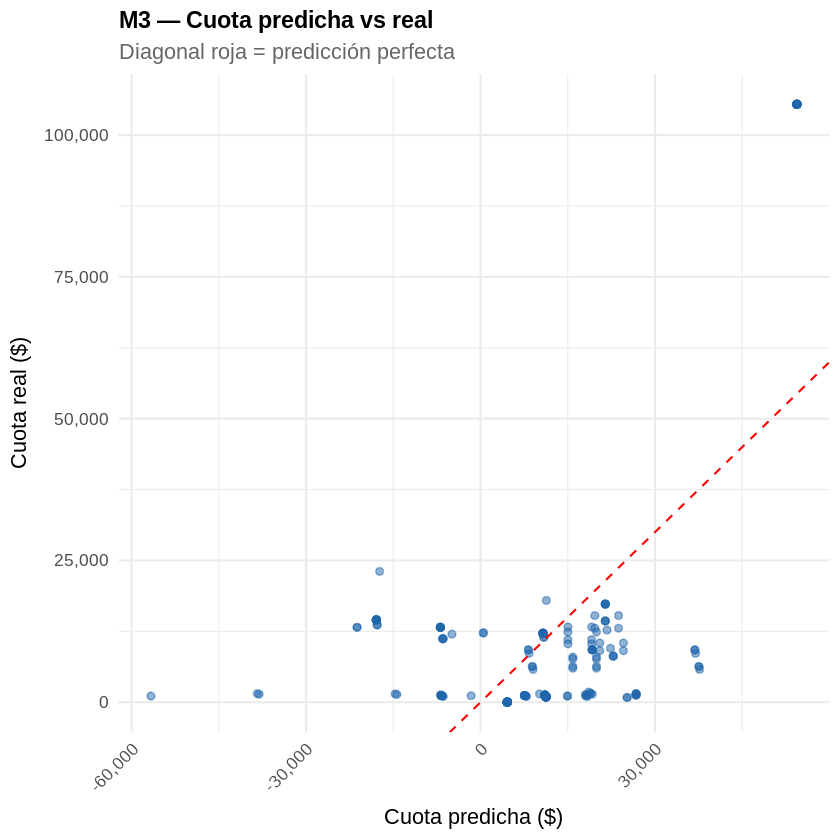

=== M3 summary ===



Call:
lm(formula = cuota_inicial ~ tasa_anual_max + plazo_max + rel_cuota_ing + 
    rel_monto_tas, data = bcra_clean)

Residuals:
   Min     1Q Median     3Q    Max 
-31902 -10293  -4585   1415  57764 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)     5545.32   15192.99   0.365    0.715    
tasa_anual_max  -128.94     328.04  -0.393    0.695    
plazo_max        -25.73      19.45  -1.323    0.187    
rel_cuota_ing  -3482.65     548.44  -6.350 8.74e-10 ***
rel_monto_tas   1432.60     110.10  13.012  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 19120 on 278 degrees of freedom
Multiple R-squared:  0.4332,	Adjusted R-squared:  0.425 
F-statistic: 53.11 on 4 and 278 DF,  p-value: < 2.2e-16


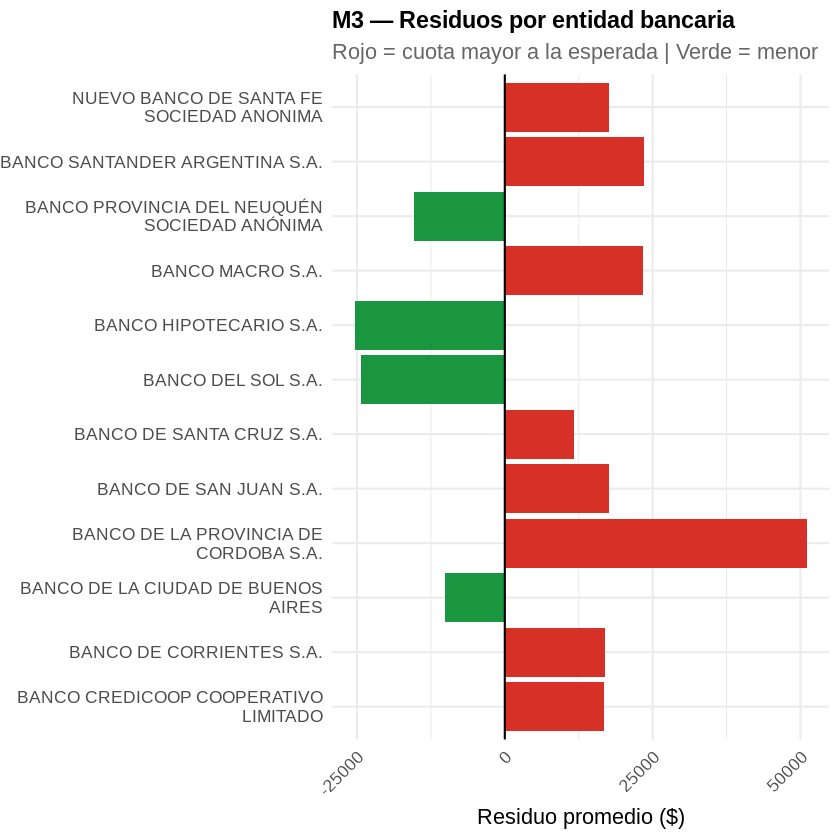

In [33]:
# ============================================================
# M3 — Cuota ~ tasa + plazo + rel_cuota_ing + rel_monto_tas
# ============================================================

m3 <- lm(cuota_inicial ~ tasa_anual_max + plazo_max +
            rel_cuota_ing + rel_monto_tas,
          data = bcra_clean)

# Predicciones vs real
bcra_clean %>%
  add_predictions(m3) %>%
  ggplot(aes(pred, cuota_inicial)) +
  geom_point(alpha = 0.5, color = "#2166ac") +
  geom_abline(slope = 1, intercept = 0,
              color = "red", linetype = "dashed") +
  scale_x_continuous(labels = scales::label_comma()) +
  scale_y_continuous(labels = scales::label_comma()) +
  labs(title = "M3 — Cuota predicha vs real",
       subtitle = "Diagonal roja = predicción perfecta",
       x = "Cuota predicha ($)", y = "Cuota real ($)")

# Residuos por entidad: ¿qué bancos cobran más/menos de lo esperado?
bcra_clean %>%
  add_residuals(m3, "resid") %>%
  group_by(entidad) %>%
  summarise(resid_medio = mean(resid), n = n()) %>%
  slice_max(abs(resid_medio), n = 12) %>%
  mutate(entidad = str_wrap(fct_reorder(entidad, resid_medio), 30)) %>%
  ggplot(aes(resid_medio, entidad,
             fill = resid_medio > 0)) +
  geom_col() +
  scale_fill_manual(values = c("TRUE" = "#d73027", "FALSE" = "#1a9641"),
                    guide = "none") +
  geom_vline(xintercept = 0) +
  labs(title = "M3 — Residuos por entidad bancaria",
       subtitle = "Rojo = cuota mayor a la esperada | Verde = menor",
       x = "Residuo promedio ($)", y = NULL)

cat("=== M3 summary ===\n")
summary(m3)

In [34]:
# ============================================================
# PASO 5 — Comparación de modelos (R4DS style)
# ============================================================

tibble(
  Modelo     = c("M1 log-log (UVA→Precio)",
                 "M2 Precio múltiple",
                 "M3 Cuota BCRA"),
  R2_adj     = c(summary(m1)$adj.r.squared,
                 summary(m2)$adj.r.squared,
                 summary(m3)$adj.r.squared),
  Residuo_SE = c(summary(m1)$sigma,
                 summary(m2)$sigma,
                 summary(m3)$sigma),
  N          = c(nrow(datos_cruzados),
                 nrow(precio_modelo),
                 nrow(bcra_clean))
) %>%
  mutate(across(where(is.numeric), ~round(., 3))) %>%
  print()

# A tibble: 3 × 4
  Modelo                  R2_adj Residuo_SE     N
  <chr>                    <dbl>      <dbl> <dbl>
1 M1 log-log (UVA→Precio)  0.507      0.062    13
2 M2 Precio múltiple       0.639    436.     3085
3 M3 Cuota BCRA            0.425  19121.      283
